# Benchmark 1D 

In [1]:
import tensorflow.keras.backend as K
from tensorflow.keras.regularizers import l2
from hyperopt import STATUS_OK, tpe, Trials, hp, fmin
from hyperopt.pyll.stochastic import sample
from hyperopt.pyll.base import scope
from sklearn.model_selection import KFold
import numpy as np
from matplotlib import pyplot as plt
from tensorflow.keras.optimizers import Adam,Nadam,Adamax
from ann_functions import getModel, kCrossVal, transfBestparam
from time import perf_counter
import tensorflow as tf
from generalization import Neural_network, MultiFidelity

from cuqi.distribution import Uniform, Gaussian,JointDistribution
from cuqi.sampler import MH, NUTS
from cuqi.model import Model
from cuqi.geometry import Continuous1D, Discrete
import keras

# Creation of the model

In [2]:
seed = 10
tf.random.set_seed(seed)
np.random.seed(seed)
keras.utils.set_random_seed(seed)

HPO = False

#Benchmark1
highfid = lambda x: (6.*x-2.)**2*np.sin(12.*x-4.)
lowfid  = lambda x: 0.5*highfid(x) + 10*(x-0.5) + 5.
Nhf = 5
Nlf = 32
N = Nhf + Nlf
xhf = np.linspace(0,1,Nhf)
xlf = np.linspace(0,1,Nlf)
x_test = np.linspace(0,1,1000)
Yhf = highfid(xhf)
Ylf = lowfid(xlf)

NepoLF = 1000
NepoHF = 500

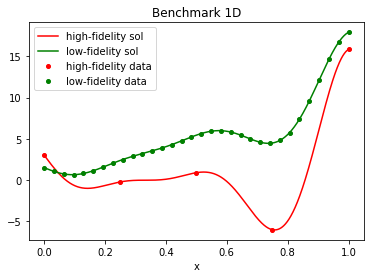

In [3]:
#%% Plot functions
plt.figure()
plt.plot(x_test,highfid(x_test),'r', label = 'high-fidelity sol')
plt.plot(x_test,lowfid(x_test),'g', label = 'low-fidelity sol')
plt.plot(xhf,highfid(xhf),'ro', label = 'high-fidelity data', markersize = 4)
plt.plot(xlf,lowfid(xlf),'go', label = 'low-fidelity data', markersize = 4)
plt.xlabel('x')
plt.legend()
plt.title('Benchmark 1D')
plt.show()

## Low fidelity model

In [4]:
bestLF_params = {'lr' : 0.0255, 'kernel_init' : 'glorot_uniform', 'opt' : 'Adam'}
modelLF=Neural_network('LF',params=bestLF_params,data_train=xlf,output_train=Ylf,N=NepoLF,n=Nlf,train=True,do_HPO=False,verbose=False)
yLF=modelLF.prediction(x_test)


## High fidelity model

In [5]:
bestHF_params = {'lr' : 0.0255, 'kernel_init' : 'glorot_uniform', 'opt' : 'Adam'}
modelHF=Neural_network('LF',params=bestHF_params,data_train=xhf,output_train=Yhf,N=NepoHF,n=Nhf,train=True,do_HPO=False,verbose=False)
yHF=modelHF.prediction(x_test)

## 2 Step model

In [6]:
bestLF_params = {'lr' : 0.0255, 'kernel_init' : 'glorot_uniform', 'opt' : 'Adam'}
best_params = {'kernel_init': 'uniform', 'l2weight': 0.00010018625799978436, 'lr': 0.07093837044166487, 'nodes': 74.0, 'opt': 'Adamax'}
N=[NepoLF,NepoHF]
n=[Nlf,Nhf]
names=['LF','2step']

params=[bestLF_params,best_params]
final_model=MultiFidelity(names,params=params,data_train_LF=xlf,output_train_LF=Ylf,data_train_HF=xhf,output_train_HF=Yhf,N=N,n=n,do_HPO=False,verbose=False)
y_test=final_model.prediction(x_test)

## Plots

Text(0.5, 1.0, 'High fidelity model - 2-step')

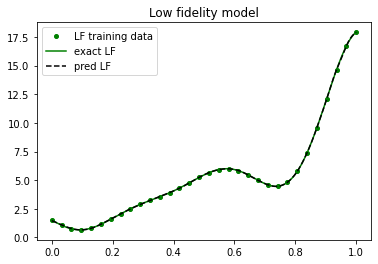

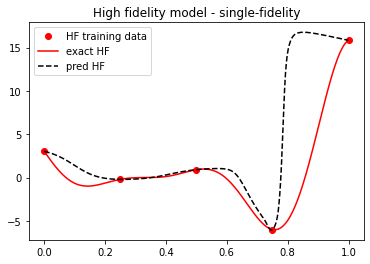

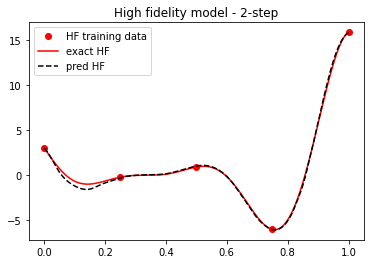

In [7]:
#LF
plt.figure()
plt.plot(xlf,Ylf,'go', label = 'LF training data', markersize = 4)
plt.plot(x_test,lowfid(x_test),'g', label = 'exact LF') 
plt.plot(x_test,yLF,'k--', label = 'pred LF')
plt.legend()
plt.title('Low fidelity model')

#HF single-fidelity
plt.figure()
plt.plot(xhf,Yhf,'ro', label = 'HF training data')
plt.plot(x_test,highfid(x_test),'-r', label = 'exact HF')
plt.plot(x_test,yHF,'--k', label = 'pred HF')
plt.legend()
plt.title('High fidelity model - single-fidelity')

#2-step MF
plt.figure()
plt.plot(xhf,Yhf,'ro', label = 'HF training data')
plt.plot(x_test,highfid(x_test),'-r', label = 'exact HF')
plt.plot(x_test,y_test,'--k', label = 'pred HF')
plt.legend()
plt.title('High fidelity model - 2-step')

# MCMC

In [8]:
real_x = np.array([0.1,0.3,0.5,0.7,0.9])
observed_output = highfid(real_x)

# Set parameters for the MCMC
n_samples = np.array([100,800,1200])  # Number of samples
initial_x = 0.5 # Initial value for x
proposal_sds = np.array([0.1,0.25,0.5,0.75,1.]) # Standard deviation for the proposal distribution
chain_length=2

### Low Fidelity

In [20]:
from scipy.interpolate import interp1d
# rendila un decorator
def estimate_gradient(x, y, new_value_x):
    """
    Calcola una stima del gradiente nei punti specificati dati gli array x e y.

    Parametri:
    - x: array NumPy contenente le coordinate x dei dati.
    - y: array NumPy contenente le coordinate y dei dati.
    - punti: array NumPy contenente i punti in cui si vuole stimare il gradiente.

    Ritorna:
    - gradiente: array NumPy contenente le stime del gradiente nei punti specificati.
    """

    # Verifica che le dimensioni di x e y siano uguali
    if x.shape != y.shape:
        raise ValueError("Le dimensioni di x e y devono essere uguali.")

    # Calcola la derivata rispetto a x
    dx = np.gradient(x)

    # Calcola la derivata rispetto a y
    dy = np.gradient(y)

    # Calcola il gradiente come rapporto tra le derivate rispetto a x e y
    gradiente = dy / dx

    # Utilizza la funzione np.interp per stimare il gradiente nei punti specificati
    gradiente_stimato = np.interp(new_value_x, x, gradiente)

    return gradiente_stimato


def gradient_LF(value):
    
    return estimate_gradient(x_test,yLF,value)

********************  # Variance = 0.1  ********************
********************  # Steps = 400  ********************
Sample 600 / 600

Average acceptance rate: 0.045 MCMC scale: 0.03047799499335852 

Sample 600 / 600

Average acceptance rate: 0.195 MCMC scale: 0.02578880706803592 

Sample 600 / 600

Average acceptance rate: 0.17 MCMC scale: 0.026094177302102457 

Sample 600 / 600

Average acceptance rate: 0.195 MCMC scale: 0.023979672118626016 

Sample 600 / 600

Average acceptance rate: 0.185 MCMC scale: 0.02247727206703131 

Sample 600 / 600

Average acceptance rate: 0.21 MCMC scale: 0.023050089547551177 

Sample 600 / 600

Average acceptance rate: 0.195 MCMC scale: 0.024149219981291006 

Sample 600 / 600

Average acceptance rate: 0.185 MCMC scale: 0.024647485011618012 

Sample 600 / 600

Average acceptance rate: 0.2275 MCMC scale: 0.025137738986447108 

Sample 600 / 600

Average acceptance rate: 0.18 MCMC scale: 0.025163159091360014 

********************  # Mean values = [0.16959

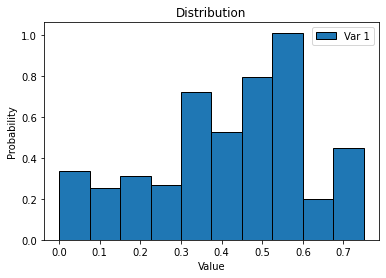

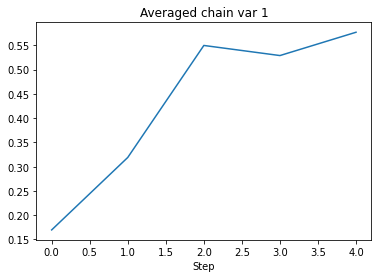

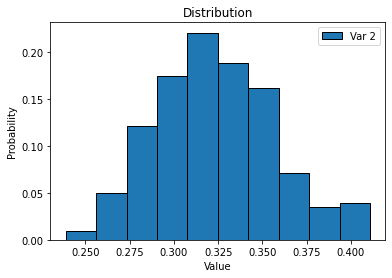

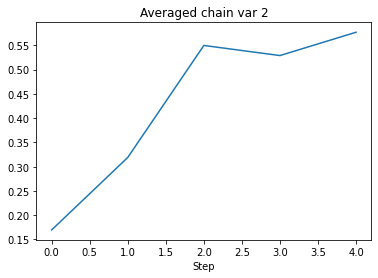

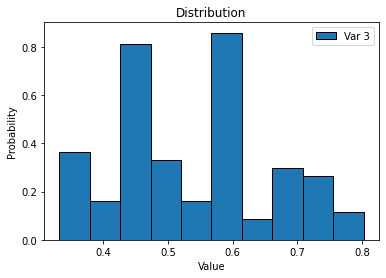

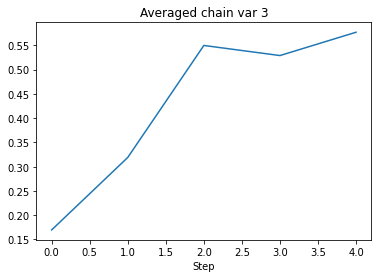

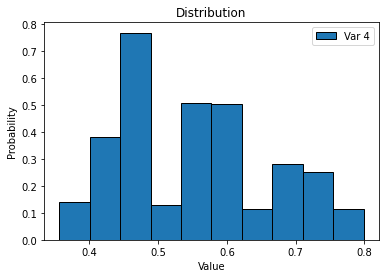

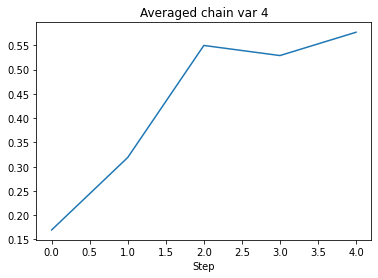

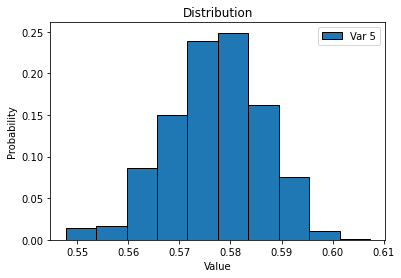

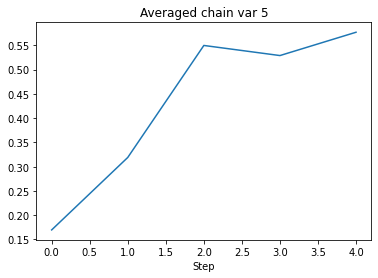

********************  # Steps = 800  ********************
Sample 1200 / 1200

Average acceptance rate: 0.02125 MCMC scale: 0.028996414627574848 

Sample 1200 / 1200

Average acceptance rate: 0.215 MCMC scale: 0.023342345904583596 

Sample 1200 / 1200

Average acceptance rate: 0.22125 MCMC scale: 0.023423199505163392 

Sample 1200 / 1200

Average acceptance rate: 0.23625 MCMC scale: 0.023283739697859303 

Sample 1200 / 1200

Average acceptance rate: 0.2125 MCMC scale: 0.024644532352736417 

Sample 1200 / 1200

Average acceptance rate: 0.1825 MCMC scale: 0.01768363962306588 

Sample 1200 / 1200

Average acceptance rate: 0.22375 MCMC scale: 0.022707585229821723 

Sample 1200 / 1200

Average acceptance rate: 0.19375 MCMC scale: 0.02335508765370106 

Sample 1200 / 1200

Average acceptance rate: 0.195 MCMC scale: 0.018135942411699395 

Sample 1200 / 1200

Average acceptance rate: 0.24125 MCMC scale: 0.02249263197218753 

********************  # Mean values = [0.1687057  0.40319291 0.53015173

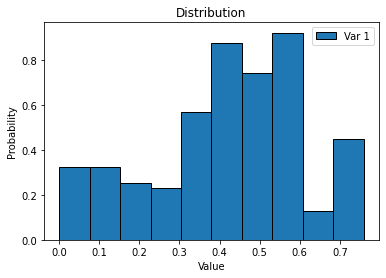

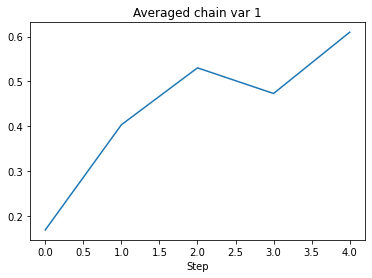

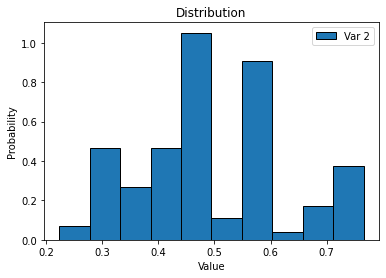

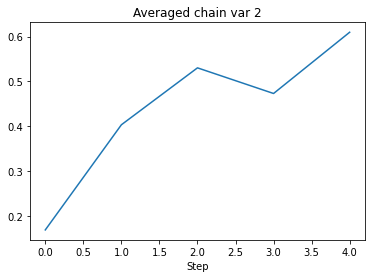

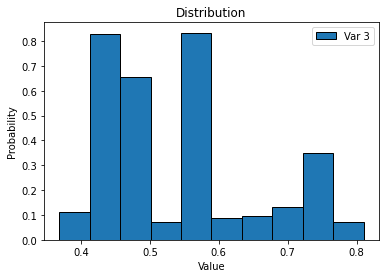

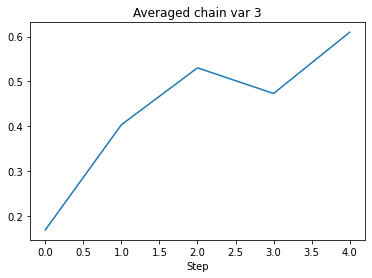

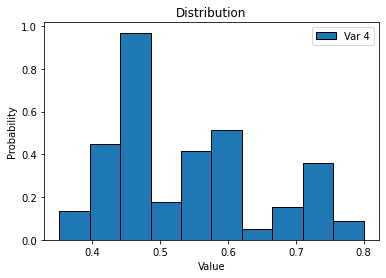

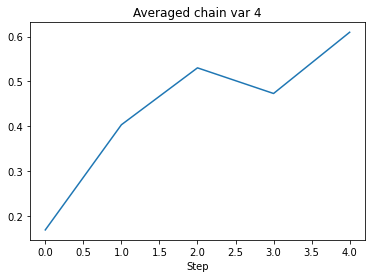

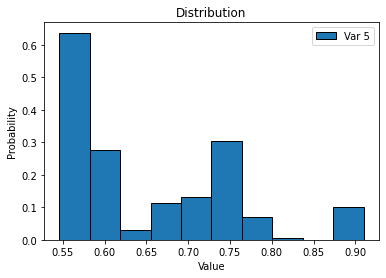

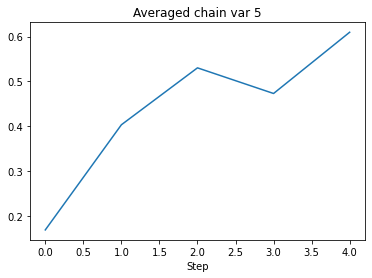

********************  # Steps = 1200  ********************
Sample 1800 / 1800

Average acceptance rate: 0.04666666666666667 MCMC scale: 0.029735421819888416 

Sample 1800 / 1800

Average acceptance rate: 0.20166666666666666 MCMC scale: 0.024355928813998683 

Sample 1800 / 1800

Average acceptance rate: 0.23 MCMC scale: 0.023016195587360917 

Sample 1800 / 1800

Average acceptance rate: 0.22083333333333333 MCMC scale: 0.02224731778523597 

Sample 1800 / 1800

Average acceptance rate: 0.21083333333333334 MCMC scale: 0.022267074339160003 

Sample 1800 / 1800

Average acceptance rate: 0.23333333333333334 MCMC scale: 0.022312074609032485 

Sample 1800 / 1800

Average acceptance rate: 0.235 MCMC scale: 0.02269903419332464 

Sample 1800 / 1800

Average acceptance rate: 0.21916666666666668 MCMC scale: 0.022511661193275665 

Sample 1800 / 1800

Average acceptance rate: 0.235 MCMC scale: 0.02336210196169502 

Sample 1800 / 1800

Average acceptance rate: 0.24083333333333334 MCMC scale: 0.02295909

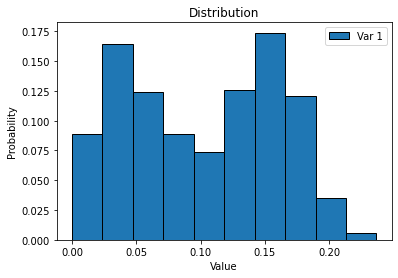

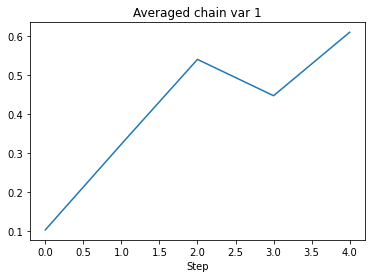

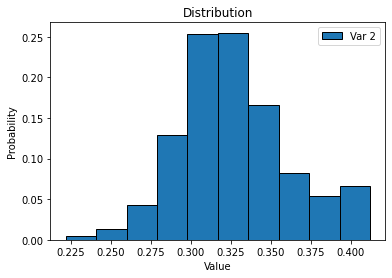

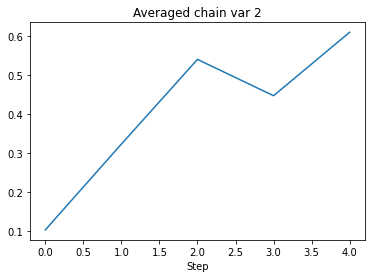

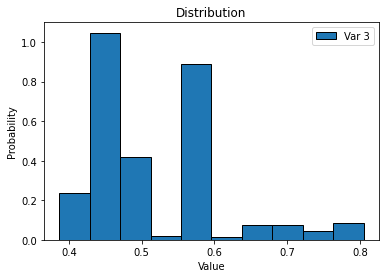

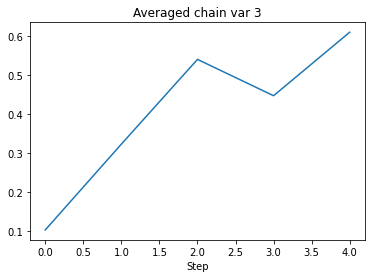

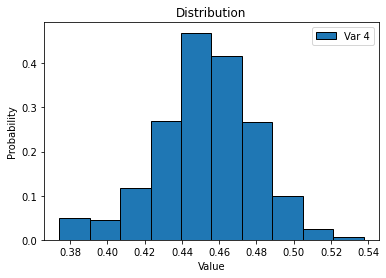

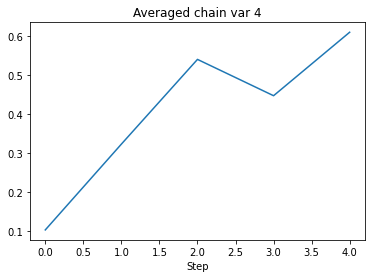

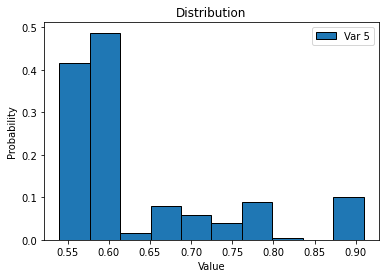

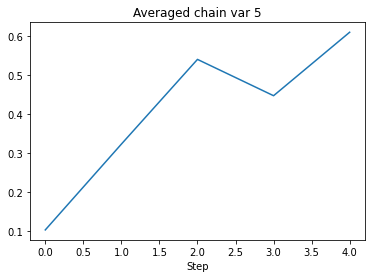

********************  # Variance = 0.25  ********************
********************  # Steps = 400  ********************
Sample 600 / 600

Average acceptance rate: 0.0625 MCMC scale: 0.03899640563367001 

Sample 600 / 600

Average acceptance rate: 0.2125 MCMC scale: 0.028208665485622366 

Sample 600 / 600

Average acceptance rate: 0.185 MCMC scale: 0.034225211738303646 

Sample 600 / 600

Average acceptance rate: 0.2025 MCMC scale: 0.024920560702757697 

Sample 600 / 600

Average acceptance rate: 0.2825 MCMC scale: 0.03625302769206772 

Sample 600 / 600

Average acceptance rate: 0.2025 MCMC scale: 0.03344022417028373 

Sample 600 / 600

Average acceptance rate: 0.265 MCMC scale: 0.035888336652412596 

Sample 600 / 600

Average acceptance rate: 0.21 MCMC scale: 0.03558017555205393 

Sample 600 / 600

Average acceptance rate: 0.175 MCMC scale: 0.02993587422354985 

Sample 600 / 600

Average acceptance rate: 0.2125 MCMC scale: 0.03044125182372668 

********************  # Mean values = [0.

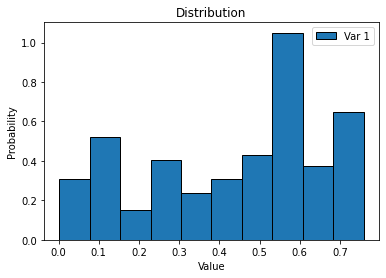

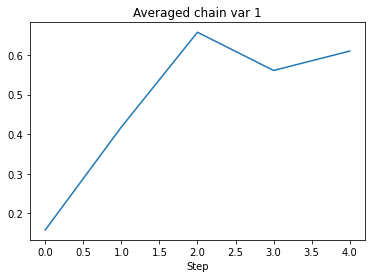

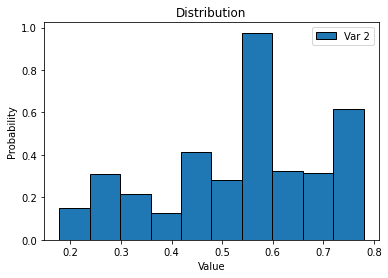

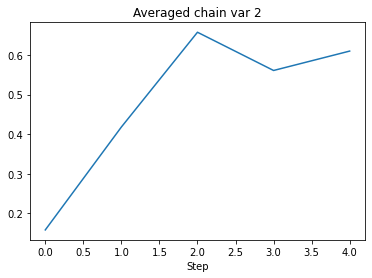

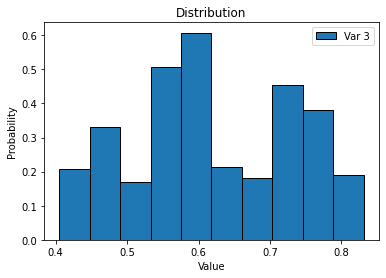

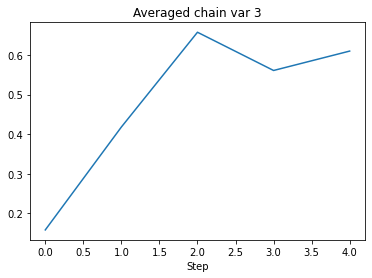

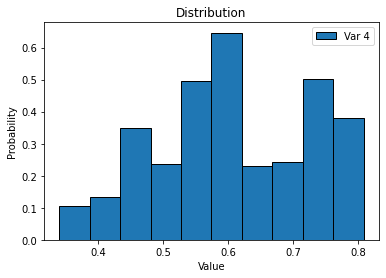

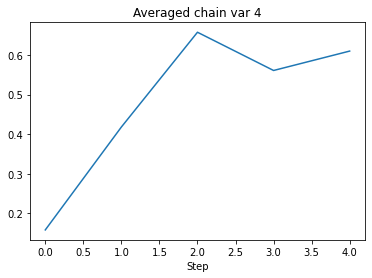

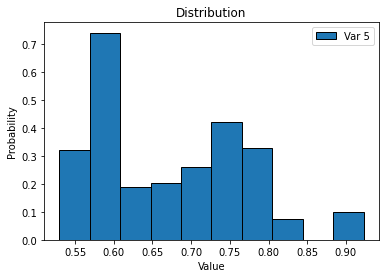

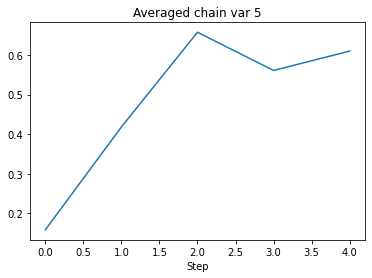

********************  # Steps = 800  ********************
Sample 1200 / 1200

Average acceptance rate: 0.07625 MCMC scale: 0.03719087860099474 

Sample 1200 / 1200

Average acceptance rate: 0.23125 MCMC scale: 0.03840135407069065 

Sample 1200 / 1200

Average acceptance rate: 0.20875 MCMC scale: 0.030997877806353717 

Sample 1200 / 1200

Average acceptance rate: 0.24875 MCMC scale: 0.03993580668059219 

Sample 1200 / 1200

Average acceptance rate: 0.19875 MCMC scale: 0.03522600301201006 

Sample 1200 / 1200

Average acceptance rate: 0.21125 MCMC scale: 0.03409722280611095 

Sample 1200 / 1200

Average acceptance rate: 0.21 MCMC scale: 0.03392147983697824 

Sample 1200 / 1200

Average acceptance rate: 0.22875 MCMC scale: 0.03803372737394925 

Sample 1200 / 1200

Average acceptance rate: 0.28125 MCMC scale: 0.03661014685484811 

Sample 1200 / 1200

Average acceptance rate: 0.21125 MCMC scale: 0.04063666906659212 

********************  # Mean values = [0.09702244 0.32035351 0.61588103 0.

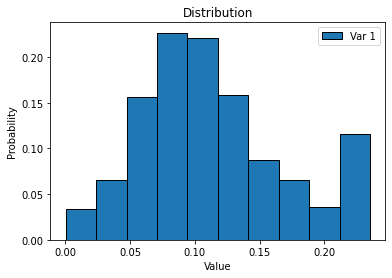

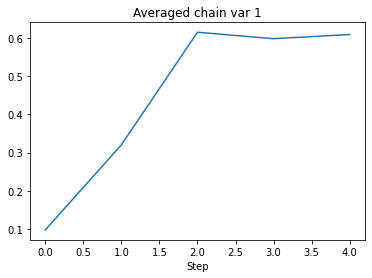

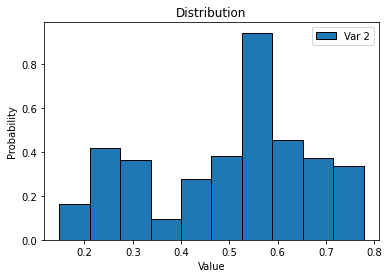

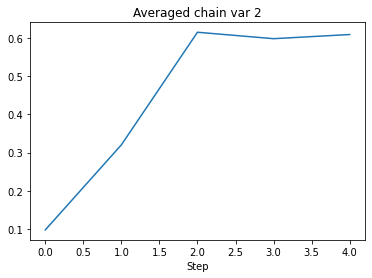

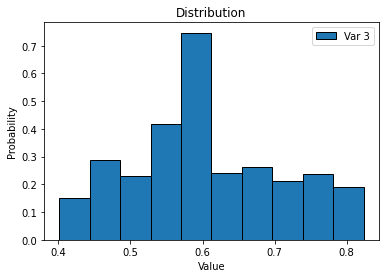

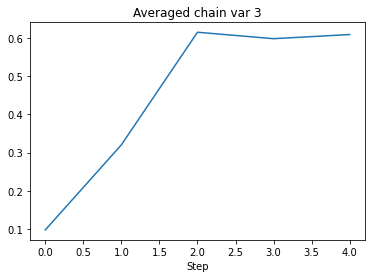

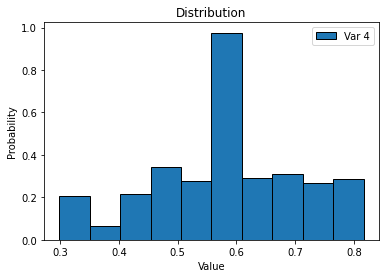

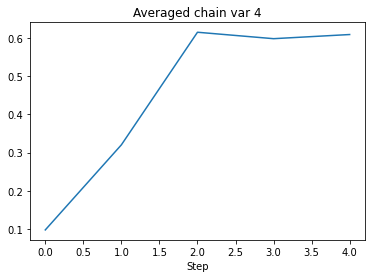

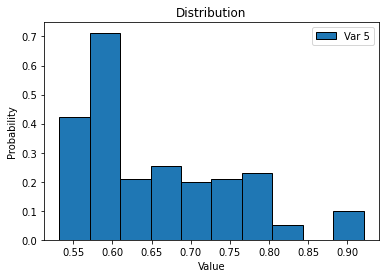

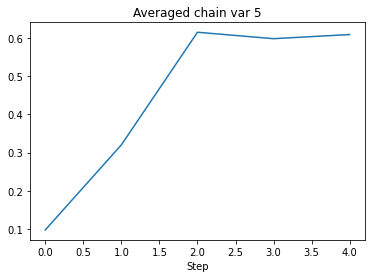

********************  # Steps = 1200  ********************
Sample 1800 / 1800

Average acceptance rate: 0.09083333333333334 MCMC scale: 0.03441724762611714 

Sample 1800 / 1800

Average acceptance rate: 0.2325 MCMC scale: 0.03545200466077747 

Sample 1800 / 1800

Average acceptance rate: 0.23833333333333334 MCMC scale: 0.0344160036003741 

Sample 1800 / 1800

Average acceptance rate: 0.185 MCMC scale: 0.02541584002801929 

Sample 1800 / 1800

Average acceptance rate: 0.22833333333333333 MCMC scale: 0.029057122342138447 

Sample 1800 / 1800

Average acceptance rate: 0.23166666666666666 MCMC scale: 0.034846828522126005 

Sample 1800 / 1800

Average acceptance rate: 0.22416666666666665 MCMC scale: 0.03508606787983067 

Sample 1800 / 1800

Average acceptance rate: 0.22333333333333333 MCMC scale: 0.035883143784027564 

Sample 1800 / 1800

Average acceptance rate: 0.23916666666666667 MCMC scale: 0.035546509697322856 

Sample 1800 / 1800

Average acceptance rate: 0.24666666666666667 MCMC scal

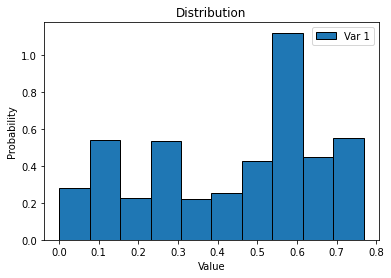

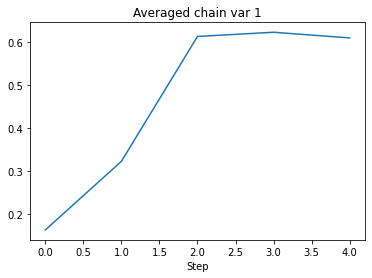

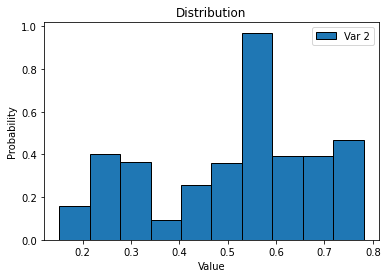

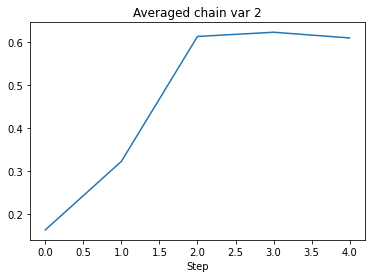

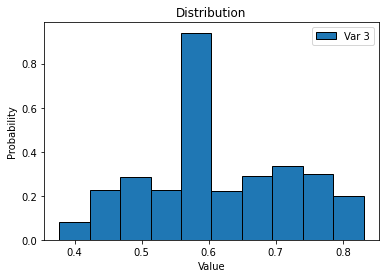

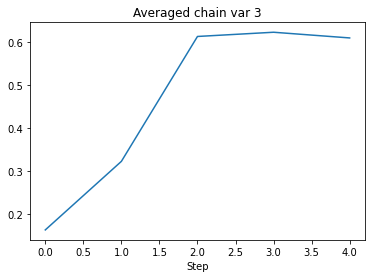

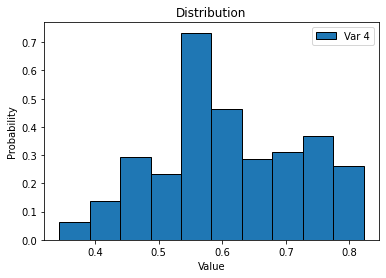

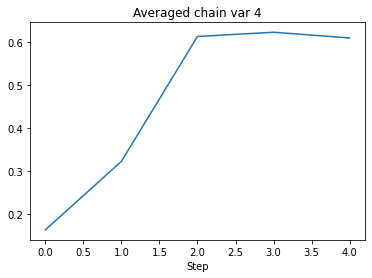

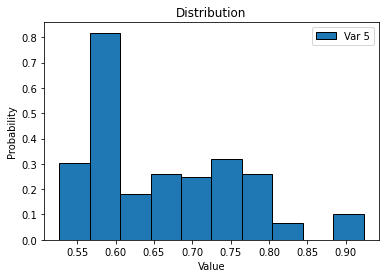

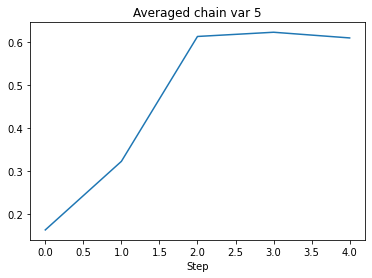

********************  # Variance = 0.5  ********************
********************  # Steps = 400  ********************
Sample 600 / 600

Average acceptance rate: 0.095 MCMC scale: 0.0375886606329163 

Sample 600 / 600

Average acceptance rate: 0.245 MCMC scale: 0.043832287966206064 

Sample 72 / 600

In [47]:
# ATTENZIONE!  in caso LF non si dovrebbe mettere comunque forward=modelHF?
A_LF=Model(forward=modelLF.prediction, range_geometry=Continuous1D(5), domain_geometry=Continuous1D(5))
x_LF=Uniform(np.array([0.,0.,0.,0.,0.]),np.array([1.,1.,1.,1.,1.]))
num_bins = 10

for sd in proposal_sds:
    print(                f"********************  # Variance = {sd}  ********************"
                )
    y_LF=Gaussian(mean=A_LF(x_LF),cov=sd)
    y_obs=y_LF(x_LF=real_x).sample()
    posterior_LF=JointDistribution(y_LF,x_LF)(y_LF=y_obs)
    x_init=np.array([initial_x,initial_x,initial_x,initial_x,initial_x])

    for N in n_samples:
        print(                f"********************  # Steps = {N}  ********************"
                )
        MHsampler_LF=MH(posterior_LF,x0=x_init)
        estimates=np.empty((x_init.shape[0],0))
        chains=np.empty((0,x_init.shape[0],N))
        post=np.empty((x_init.shape[0],0))
        for i in range(chain_length):
                samplesMH_LF=MHsampler_LF.sample_adapt(N,int(N/2))    # N: number of "real" steps Nb: number of burn-in steps # total nb of steps is the sum of the two
                estimates=np.column_stack((estimates,samplesMH_LF.mean()[:, np.newaxis]))
                # chains=np.concatenate(chains, samplesMH_LF.samples)
                chains = np.concatenate((chains, np.expand_dims(samplesMH_LF.samples, axis=0)), axis=0)

                post=np.concatenate((post,samplesMH_LF.samples),axis=1)
        
        print(                f"********************  # Mean values = {estimates.mean(axis=1)}  ********************"
                )
          
        for num in range(post.shape[0]):        
                bin_edges = np.linspace(np.min(post[num,:]), np.max(post[num,:]), num_bins + 1)
                hist, _ = np.histogram(post, bins=bin_edges)
                hist=hist/post.shape[1]
                bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
                plt.figure()
                plt.bar(bin_centers, hist, width=np.diff(bin_edges), edgecolor='black', label=f'Var {num + 1}')

                plt.xlabel('Value')
                plt.ylabel('Probability')
                plt.title('Distribution')
                plt.legend()
                plt.show()
                
                # plt.figure()
                # plt.plot(np.mean(chains,axis=(0,2)))
                # plt.xlabel('Step')
                # plt.title(f'Averaged chain var {num+1}')
                # plt.show()

                
                
                
# samplesMH_LF.plot_trace()
# print("mean value")
# print(samplesMH_LF.mean())
# print("ESS")
# print(samplesMH_LF.compute_ess())
# samplesMH_LF.plot_autocorrelation()

In [27]:
from cuqi.distribution import Beta

In [33]:
real_x = np.array([0.1,0.3,0.5,0.7,0.9])
observed_output = highfid(real_x)

# Set parameters for the MCMC
n_samples = np.array([10,800,1200])  # Number of samples
initial_x = 0.5 # Initial value for x
proposal_sds = np.array([0.1,0.25,0.5,0.75,1.]) # Standard deviation for the proposal distribution
chain_length=2

********************  # Variance = 0.1  ********************
********************  # Steps = 10  ********************


Sample 15 / 15
Sample 15 / 15
********************  # Mean values = [0.30188455 0.44248868 0.46951089 0.51347088 0.54969043]  ********************


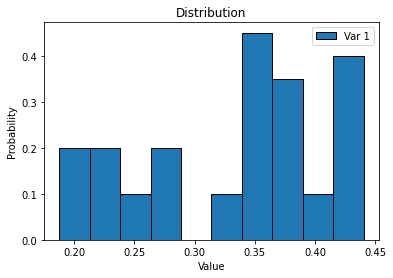

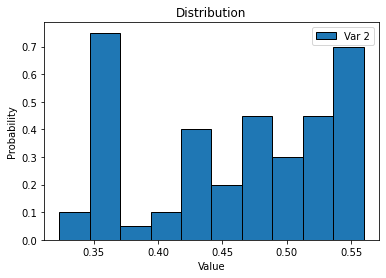

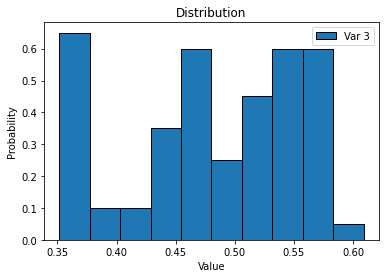

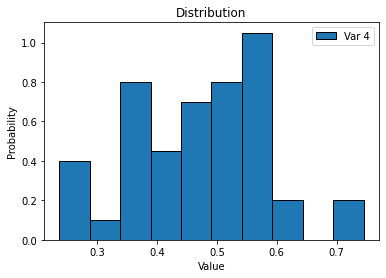

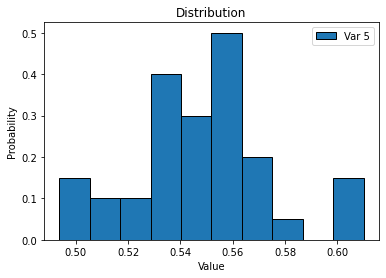

********************  # Steps = 800  ********************
Sample 1200 / 1200
Sample 1200 / 1200
********************  # Mean values = [0.48887202 0.48154788 0.48417455 0.48368852 0.49635091]  ********************


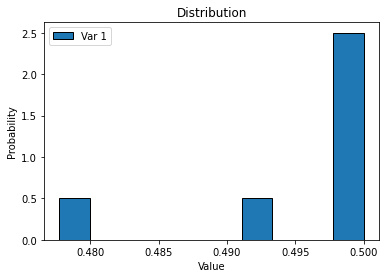

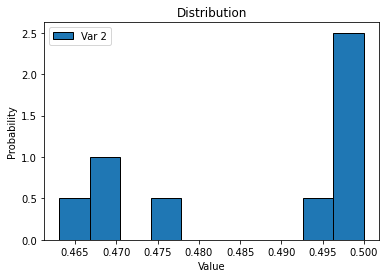

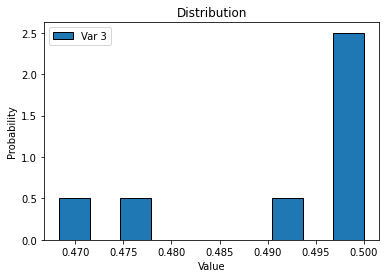

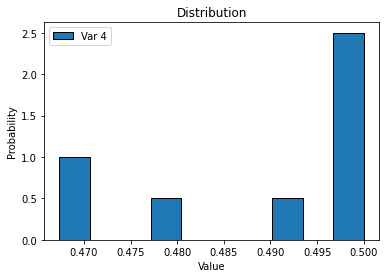

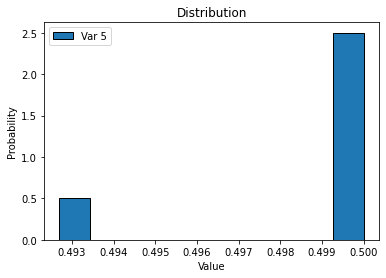

********************  # Steps = 1200  ********************
Sample 1800 / 1800


KeyboardInterrupt: 

In [34]:
A_LF=Model(forward=modelLF.prediction, jacobian=gradient_LF,range_geometry=Continuous1D(5), domain_geometry=Continuous1D(5))
x_LF=Beta(alpha=2*np.ones(5),beta=2*np.ones(5))  # <------
num_bins = 10

for sd in proposal_sds:
    print(                f"********************  # Variance = {sd}  ********************"
                )
    y_LF=Gaussian(mean=A_LF(x_LF),cov=sd)
    y_obs=y_LF(x_LF=real_x).sample()
    posterior_LF=JointDistribution(y_LF,x_LF)(y_LF=y_obs)
    x_init=np.array([initial_x,initial_x,initial_x,initial_x,initial_x])

    for N in n_samples:
        print(                f"********************  # Steps = {N}  ********************"
                )
        MHsampler_LF=NUTS(posterior_LF,x0=x_init)
        estimates=np.empty((x_init.shape[0],0))
        chains=np.empty((0,x_init.shape[0],N))
        post=np.empty((x_init.shape[0],0))
        for i in range(chain_length):
                samplesMH_LF=MHsampler_LF.sample_adapt(N,int(N/2))    # N: number of "real" steps Nb: number of burn-in steps # total nb of steps is the sum of the two
                estimates=np.column_stack((estimates,samplesMH_LF.mean()[:, np.newaxis]))
                # chains=np.concatenate(chains, samplesMH_LF.samples)
                chains = np.concatenate((chains, np.expand_dims(samplesMH_LF.samples, axis=0)), axis=0)

                post=np.concatenate((post,samplesMH_LF.samples),axis=1)
        
        print(                f"********************  # Mean values = {estimates.mean(axis=1)}  ********************"
                )
          
        for num in range(post.shape[0]):        
                bin_edges = np.linspace(np.min(post[num,:]), np.max(post[num,:]), num_bins + 1)
                hist, _ = np.histogram(post, bins=bin_edges)
                hist=hist/post.shape[1]
                bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
                plt.figure()
                plt.bar(bin_centers, hist, width=np.diff(bin_edges), edgecolor='black', label=f'Var {num + 1}')

                plt.xlabel('Value')
                plt.ylabel('Probability')
                plt.title('Distribution')
                plt.legend()
                plt.show()
                
                # plt.figure()
                # plt.plot(np.mean(chains,axis=(0,2)))
                # plt.xlabel('Step')
                # plt.title(f'Averaged chain var {num+1}')
                # plt.show()

                
                
                
# samplesMH_LF.plot_trace()
# print("mean value")
# print(samplesMH_LF.mean())
# print("ESS")
# print(samplesMH_LF.compute_ess())
# samplesMH_LF.plot_autocorrelation()

In [ ]:
# #proposal_sd=np.exp(-(d-y_obs)**2/(np.sqrt(2*0.3)))

# A_LF=Model(forward=modelLF.prediction, range_geometry=Continuous1D(5), domain_geometry=Continuous1D(5))
# x_LF=Uniform(np.array([0.,0.,0.,0.,0.]),np.array([1.,1.,1.,1.,1.]))

# d=Uniform(np.array([0.,0.,0.,0.,0.]),np.array([1.,1.,1.,1.,1.]))

# y_LF=Gaussian(A_LF(x_LF),lambda d: np.exp(-(d-modelHF.prediction(real_x))**2/(np.sqrt(2*0.3))))      # ATTENZIONE! NON SO SE SENSATO METTERE QUA PREDICTION, A QUEL PUNTO RUOLO DI y_obs sotto? E poi, si deve valutare NN(x_step) o  NN(real_x)?
# y_obs=y_LF(x_LF=real_x, d=0.1*np.ones(5)).sample()    # d=modelLF.prediction(real_x)
# posterior_LF=JointDistribution(y_LF,x_LF,d)(y_LF=y_obs)
# x_init=np.array([initial_x,initial_x,initial_x,initial_x,initial_x])
# MHsampler_LF = MH(posterior_LF, x0=x_init)   #x0=np.vstack(x_init, modelLF.prediction(x_init)

# estimates=np.empty((x_init.shape[0],0))
# chains=np.empty((0,x_init.shape[0],n_samples))

# chain_length=8
# n_samples=600
# for i in range(chain_length):
#     samplesMH_LF=MHsampler_LF.sample_adapt(n_samples,int(n_samples/2))    # N: number of "real" steps Nb: number of burn-in steps # total nb of steps is the sum of the two
#     estimates=np.column_stack((estimates,samplesMH_LF.mean()[:, np.newaxis]))
#     # chains=np.concatenate(chains, samplesMH_LF.samples)
#     chains = np.concatenate((chains, np.expand_dims(samplesMH_LF.samples, axis=0)), axis=0)

    
# print(samplesMH_LF.mean().shape)    
# print(estimates)
# print(estimates.shape)
# print(chains.shape)    

# print("MEAN VALUES")
# print(estimates.mean(axis=1))

# # samplesMH_LF.plot_trace()
# # print("mean value")
# # print(samplesMH_LF.mean())
# # print("ESS")
# # print(samplesMH_LF.compute_ess())
# # samplesMH_LF.plot_autocorrelation()

In [ ]:
#plt.plot(samplesMH_LF.samples[0,:])

In [ ]:
# samplesMH_LF.plot_violin()

In [ ]:
# A_HF=Model(forward=modelHF.prediction, range_geometry=Continuous1D(5), domain_geometry=Continuous1D(5))
# x_HF=Uniform(np.array([0.,0.,0.,0.,0.]),np.array([1.,1.,1.,1.,1.]))
# y_HF=Gaussian(mean=A_HF(x_HF),cov=proposal_sd)
# y_obs=y_HF(x_HF=real_x).sample()
# posterior_HF=JointDistribution(y_HF,x_HF)(y_HF=y_obs)
# x_init=np.array([initial_x,initial_x,initial_x,initial_x,initial_x])

# MHsampler_HF=MH(posterior_HF,x0=x_init)
# samplesMH_HF=MHsampler_HF.sample_adapt(n_samples,n_samples)

# samplesMH_HF.plot_trace()
# print(samplesMH_HF.mean())
# print(samplesMH_HF.compute_ess())
# samplesMH_HF.plot_autocorrelation()

### High Fidelity

In [ ]:
A_HF=Model(forward=modelHF.prediction, range_geometry=Continuous1D(5), domain_geometry=Continuous1D(5))
x_HF=Uniform(np.array([0.,0.,0.,0.,0.]),np.array([1.,1.,1.,1.,1.]))
num_bins = 10

for sd in proposal_sds:
    print(                f"********************  # Variance = {sd}  ********************"
                )
    y_HF=Gaussian(mean=A_HF(x_HF),cov=sd)
    y_obs=y_HF(x_HF=real_x).sample()
    posterior_HF=JointDistribution(y_HF,x_HF)(y_HF=y_obs)
    x_init=np.array([initial_x,initial_x,initial_x,initial_x,initial_x])

    for N in n_samples:
        print(                f"********************  # Steps = {N}  ********************"
                )
        MHsampler_HF=MH(posterior_HF,x0=x_init)
        estimates=np.empty((x_init.shape[0],0))
        chains=np.empty((0,x_init.shape[0],N))
        post=np.empty((x_init.shape[0],0))
        for i in range(chain_length):
                samplesMH_HF=MHsampler_LF.sample_adapt(N,int(N/2))    # N: number of "real" steps Nb: number of burn-in steps # total nb of steps is the sum of the two
                estimates=np.column_stack((estimates,samplesMH_HF.mean()[:, np.newaxis]))
                # chains=np.concatenate(chains, samplesMH_LF.samples)
                chains = np.concatenate((chains, np.expand_dims(samplesMH_HF.samples, axis=0)), axis=0)

                post=np.concatenate((post,samplesMH_HF.samples),axis=1)
        
        print(                f"********************  # Mean values = {estimates.mean(axis=1)}  ********************"
                )
          
        for num in range(post.shape[0]):        
                bin_edges = np.linspace(np.min(post[num,:]), np.max(post[num,:]), num_bins + 1)
                hist, _ = np.histogram(post, bins=bin_edges)
                hist=hist/post.shape[1]
                bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
                plt.figure()
                plt.bar(bin_centers, hist, width=np.diff(bin_edges), edgecolor='black', label=f'Var {num + 1}')

                plt.xlabel('Value')
                plt.ylabel('Probability')
                plt.title('Distribution')
                plt.legend()
                plt.show()
                
                plt.figure()
                plt.plot(np.mean(chains,axis=(0,2)))
                plt.xlabel('Step')
                plt.title(f'Averaged chain var {num+1}')
                plt.show()

                
   

### MultiFidelity

In [ ]:
A_MF=Model(forward=final_model.prediction, range_geometry=Continuous1D(5), domain_geometry=Continuous1D(5))
x_MF=Uniform(np.array([0.,0.,0.,0.,0.]),np.array([1.,1.,1.,1.,1.]))
num_bins = 10

for sd in proposal_sds:
    print(                f"********************  # Variance = {sd}  ********************"
                )
    y_MF=Gaussian(mean=A_MF(x_MF),cov=sd)
    y_obs=y_MF(x_MF=real_x).sample()
    posterior_MF=JointDistribution(y_MF,x_MF)(y_MF=y_obs)
    x_init=np.array([initial_x,initial_x,initial_x,initial_x,initial_x])

    for N in n_samples:
        print(                f"********************  # Steps = {N}  ********************"
                )
        MHsampler_MF=MH(posterior_MF,x0=x_init)
        estimates=np.empty((x_init.shape[0],0))
        chains=np.empty((0,x_init.shape[0],N))
        post=np.empty((x_init.shape[0],0))
        for i in range(chain_length):
                samplesMH_MF=MHsampler_MF.sample_adapt(N,int(N/2))    # N: number of "real" steps Nb: number of burn-in steps # total nb of steps is the sum of the two
                estimates=np.column_stack((estimates,samplesMH_MF.mean()[:, np.newaxis]))
                # chains=np.concatenate(chains, samplesMH_LF.samples)
                chains = np.concatenate((chains, np.expand_dims(samplesMH_MF.samples, axis=0)), axis=0)

                post=np.concatenate((post,samplesMH_MF.samples),axis=1)
        
        print(                f"********************  # Mean values = {estimates.mean(axis=1)}  ********************"
                )
          
        for num in range(post.shape[0]):        
                bin_edges = np.linspace(np.min(post[num,:]), np.max(post[num,:]), num_bins + 1)
                hist, _ = np.histogram(post, bins=bin_edges)
                hist=hist/post.shape[1]
                bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
                plt.figure()
                plt.bar(bin_centers, hist, width=np.diff(bin_edges), edgecolor='black', label=f'Var {num + 1}')

                plt.xlabel('Value')
                plt.ylabel('Probability')
                plt.title('Distribution')
                plt.legend()
                plt.show()
                
                plt.figure()
                plt.plot(np.mean(chains,axis=(0,2)))
                plt.xlabel('Step')
                plt.title(f'Averaged chain var {num+1}')
                plt.show()

                
   

Sample 600 / 600

Average acceptance rate: 0.13666666666666666 MCMC scale: 0.04012786795875335 



array([0.23507817, 0.53022968, 0.51405922, 0.21669816, 0.52535724])

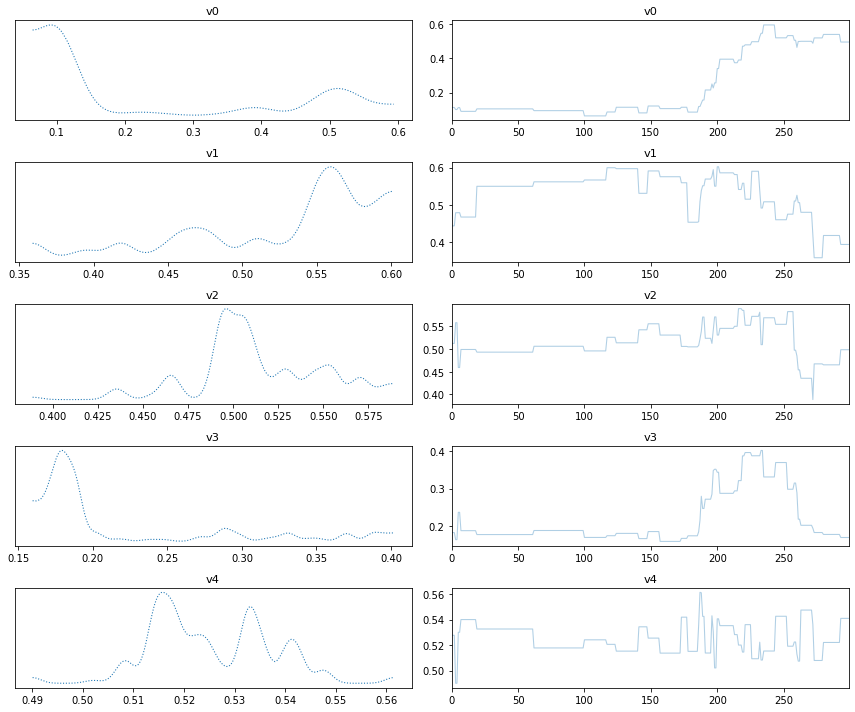

In [ ]:
# CODE SIMPLE

# A_MF=Model(forward=final_model.prediction, range_geometry=Continuous1D(5), domain_geometry=Continuous1D(5))
# x_MF=Uniform(np.array([0.,0.,0.,0.,0.]),np.array([1.,1.,1.,1.,1.]))
# y_MF=Gaussian(mean=A_MF(x_MF),cov=proposal_sd)
# y_obs=y_MF(x_MF=real_x).sample()
# posterior_MF=JointDistribution(y_MF,x_MF)(y_MF=y_obs)
# x_init=np.array([initial_x,initial_x,initial_x,initial_x,initial_x])

# MHsampler_MF=MH(posterior_MF,x0=x_init)
# samplesMH_MF=MHsampler_MF.sample_adapt(n_samples,n_samples)

# samplesMH_MF.plot_trace()
# samplesMH_MF.mean()
# samplesMH_MF.compute_ess()
# samplesMH_MF.plot_autocorrelation()

# Discontinuous Benchmark

In [ ]:
lowfid = lambda x: (0.5*(6.*x-2.)**2*np.sin(12.*x-4)+10.*(x-0.5)-5.)*(x<0.5) + (3+0.5*(6.*x-2)**2*np.sin(12.*x-4)+10*(x-0.5)-5.)*(x>0.5)
highfid = lambda x: (2*lowfid(x)- 20*x+20)*(x<0.5) + (4+2*lowfid(x)- 20*x+20)*(x>0.5)
Nhf = 6
Nlf = 32
N = Nhf + Nlf
xhf = np.linspace(0,1,Nhf)
xlf = np.linspace(0,1,Nlf)
x_test = np.linspace(0,1,1000)
Yhf = highfid(xhf)
Ylf = lowfid(xlf)
NepoLF = 5000
NepoHF = 1200

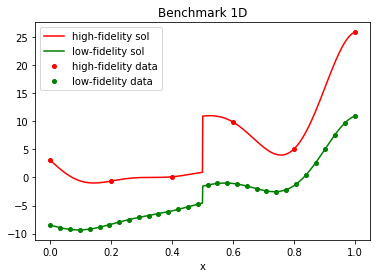

In [ ]:
#%% Plot functions
plt.figure()
plt.plot(x_test,highfid(x_test),'r', label = 'high-fidelity sol')
plt.plot(x_test,lowfid(x_test),'g', label = 'low-fidelity sol')
plt.plot(xhf,highfid(xhf),'ro', label = 'high-fidelity data', markersize = 4)
plt.plot(xlf,lowfid(xlf),'go', label = 'low-fidelity data', markersize = 4)
plt.xlabel('x')
plt.legend()
plt.title('Benchmark 1D')
plt.show()

## Low fidelity model

In [ ]:
bestLF_params = {'lr' : 0.0255, 'kernel_init' : 'glorot_uniform', 'opt' : 'Adam'}
modelLF=Neural_network('LF',params=bestLF_params,data_train=xlf,output_train=Ylf,N=NepoLF,n=Nlf,train=True,do_HPO=False,verbose=False)
yLF=modelLF.prediction(x_test)

## High fidelity model

In [ ]:
bestHF_params = {'lr' : 0.0255, 'kernel_init' : 'glorot_uniform', 'opt' : 'Adam'}
modelHF=Neural_network('LF',params=bestHF_params,data_train=xhf,output_train=Yhf,N=NepoHF,n=Nhf,train=True,do_HPO=False,verbose=False)
yHF=modelHF.prediction(x_test)

## 2 Step model

In [ ]:
bestLF_params = {'lr' : 0.0255, 'kernel_init' : 'glorot_uniform', 'opt' : 'Adam'}
best_params = {'kernel_init': 'uniform', 'l2weight': 0.00010018625799978436, 'lr': 0.07093837044166487, 'nodes': 74.0, 'opt': 'Adamax'}
N=[NepoLF,NepoHF]
n=[Nlf,Nhf]
names=['LF','2step']

params=[bestLF_params,best_params]
final_model=MultiFidelity(names,params=params,data_train_LF=xlf,output_train_LF=Ylf,data_train_HF=xhf,output_train_HF=Yhf,N=N,n=n,do_HPO=False,verbose=False)
y_test=final_model.prediction(x_test)

## Plots

Text(0.5, 1.0, 'High fidelity model - 2-step')

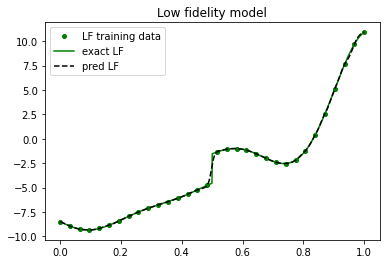

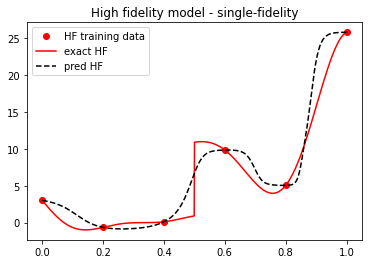

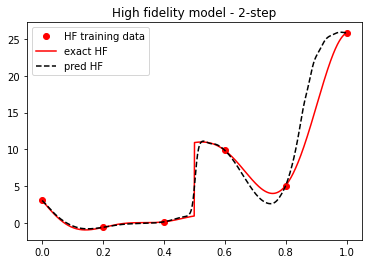

In [ ]:
#LF
plt.figure()
plt.plot(xlf,Ylf,'go', label = 'LF training data', markersize = 4)
plt.plot(x_test,lowfid(x_test),'g', label = 'exact LF') 
plt.plot(x_test,yLF,'k--', label = 'pred LF')
plt.legend()
plt.title('Low fidelity model')

#HF single-fidelity
plt.figure()
plt.plot(xhf,Yhf,'ro', label = 'HF training data')
plt.plot(x_test,highfid(x_test),'-r', label = 'exact HF')
plt.plot(x_test,yHF,'--k', label = 'pred HF')
plt.legend()
plt.title('High fidelity model - single-fidelity')

#2-step MF
plt.figure()
plt.plot(xhf,Yhf,'ro', label = 'HF training data')
plt.plot(x_test,highfid(x_test),'-r', label = 'exact HF')
plt.plot(x_test,y_test,'--k', label = 'pred HF')
plt.legend()
plt.title('High fidelity model - 2-step')

# MCMC

In [ ]:
real_x = np.array([0.1,0.3,0.5,0.7,0.9])
observed_output = highfid(real_x)

# Set parameters for the MCMC
n_samples = np.array([400,800,1200])  # Number of samples
initial_x = 0.5 # Initial value for x
proposal_sds = np.array([0.1,0.25,0.5,0.75,1.]) # Standard deviation for the proposal distribution
chain_length=10

### Low Fidelity

Sample 600 / 600

Average acceptance rate: 0.08 MCMC scale: 0.02923669614702552 



array([0.08784438, 0.7327627 , 0.75940412, 0.71632442, 0.89857366])

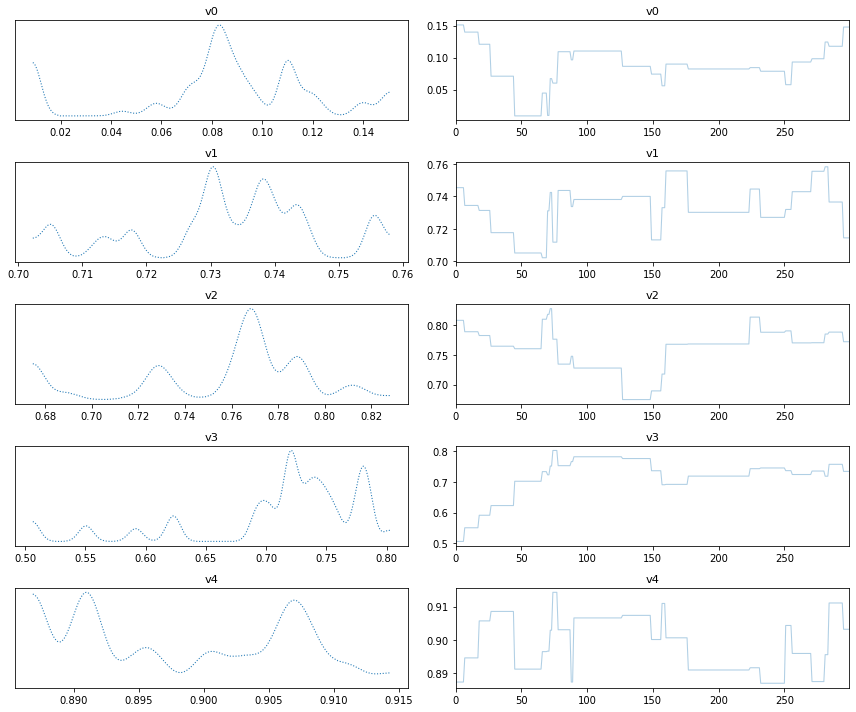

In [ ]:
# A_LF=Model(forward=modelLF.prediction, range_geometry=Continuous1D(5), domain_geometry=Continuous1D(5))
# x_LF=Uniform(np.array([0.,0.,0.,0.,0.]),np.array([1.,1.,1.,1.,1.]))
# y_LF=Gaussian(mean=A_LF(x_LF),cov=proposal_sd)
# y_obs=y_LF(x_LF=real_x).sample()
# posterior_LF=JointDistribution(y_LF,x_LF)(y_LF=y_obs)
# x_init=np.array([initial_x,initial_x,initial_x,initial_x,initial_x])

# MHsampler_LF=MH(posterior_LF,x0=x_init)
# samplesMH_LF=MHsampler_LF.sample_adapt(n_samples,n_samples)

# samplesMH_LF.plot_trace()
# samplesMH_LF.mean()
# samplesMH_LF.compute_ess()
# samplesMH_LF.plot_autocorrelation()

A_LF=Model(forward=modelLF.prediction, range_geometry=Continuous1D(5), domain_geometry=Continuous1D(5))
x_LF=Uniform(np.array([0.,0.,0.,0.,0.]),np.array([1.,1.,1.,1.,1.]))
num_bins = 10

for sd in proposal_sds:
    print(                f"********************  # Variance = {sd}  ********************"
                )
    y_LF=Gaussian(mean=A_LF(x_LF),cov=sd)
    y_obs=y_LF(x_LF=real_x).sample()
    posterior_LF=JointDistribution(y_LF,x_LF)(y_LF=y_obs)
    x_init=np.array([initial_x,initial_x,initial_x,initial_x,initial_x])

    for N in n_samples:
        print(                f"********************  # Steps = {N}  ********************"
                )
        MHsampler_LF=MH(posterior_LF,x0=x_init)
        estimates=np.empty((x_init.shape[0],0))
        chains=np.empty((0,x_init.shape[0],N))
        post=np.empty((x_init.shape[0],0))
        for i in range(chain_length):
                samplesMH_LF=MHsampler_LF.sample_adapt(N,int(N/2))    # N: number of "real" steps Nb: number of burn-in steps # total nb of steps is the sum of the two
                estimates=np.column_stack((estimates,samplesMH_LF.mean()[:, np.newaxis]))
                # chains=np.concatenate(chains, samplesMH_LF.samples)
                chains = np.concatenate((chains, np.expand_dims(samplesMH_LF.samples, axis=0)), axis=0)

                post=np.concatenate((post,samplesMH_LF.samples),axis=1)
        
        print(                f"********************  # Mean values = {estimates.mean(axis=1)}  ********************"
                )
          
        for num in range(post.shape[0]):        
                bin_edges = np.linspace(np.min(post[num,:]), np.max(post[num,:]), num_bins + 1)
                hist, _ = np.histogram(post, bins=bin_edges)
                hist=hist/post.shape[1]
                bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
                plt.figure()
                plt.bar(bin_centers, hist, width=np.diff(bin_edges), edgecolor='black', label=f'Var {num + 1}')

                plt.xlabel('Value')
                plt.ylabel('Probability')
                plt.title('Distribution')
                plt.legend()
                plt.show()
                
                plt.figure()
                plt.plot(np.mean(chains,axis=(0,2)))
                plt.xlabel('Step')
                plt.title(f'Averaged chain var {num+1}')
                plt.show()

    

### High Fidelity

Sample 600 / 600

Average acceptance rate: 0.016666666666666666 MCMC scale: 0.028623634936841127 



array([0.24195301, 0.26909351, 0.70804902, 0.6875657 , 0.89636388])

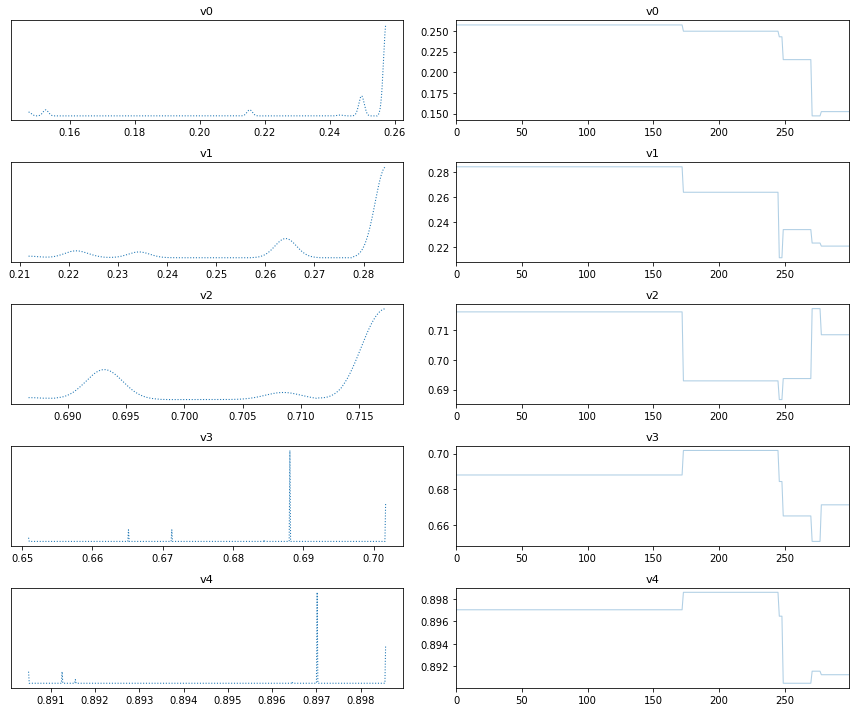

In [ ]:
# A_HF=Model(forward=modelHF.prediction, range_geometry=Continuous1D(5), domain_geometry=Continuous1D(5))
# x_HF=Uniform(np.array([0.,0.,0.,0.,0.]),np.array([1.,1.,1.,1.,1.]))
# y_HF=Gaussian(mean=A_HF(x_HF),cov=proposal_sd)
# y_obs=y_HF(x_HF=real_x).sample()
# posterior_HF=JointDistribution(y_HF,x_HF)(y_HF=y_obs)
# x_init=np.array([initial_x,initial_x,initial_x,initial_x,initial_x])

# MHsampler_HF=MH(posterior_HF,x0=x_init)
# samplesMH_HF=MHsampler_HF.sample_adapt(n_samples,n_samples)

# samplesMH_HF.plot_trace()
# samplesMH_HF.mean()
# samplesMH_HF.compute_ess()
# samplesMH_HF.plot_autocorrelation()

A_HF=Model(forward=modelHF.prediction, range_geometry=Continuous1D(5), domain_geometry=Continuous1D(5))
x_HF=Uniform(np.array([0.,0.,0.,0.,0.]),np.array([1.,1.,1.,1.,1.]))
num_bins = 10

for sd in proposal_sds:
    print(                f"********************  # Variance = {sd}  ********************"
                )
    y_HF=Gaussian(mean=A_HF(x_HF),cov=sd)
    y_obs=y_HF(x_HF=real_x).sample()
    posterior_HF=JointDistribution(y_HF,x_HF)(y_HF=y_obs)
    x_init=np.array([initial_x,initial_x,initial_x,initial_x,initial_x])

    for N in n_samples:
        print(                f"********************  # Steps = {N}  ********************"
                )
        MHsampler_HF=MH(posterior_HF,x0=x_init)
        estimates=np.empty((x_init.shape[0],0))
        chains=np.empty((0,x_init.shape[0],N))
        post=np.empty((x_init.shape[0],0))
        for i in range(chain_length):
                samplesMH_HF=MHsampler_LF.sample_adapt(N,int(N/2))    # N: number of "real" steps Nb: number of burn-in steps # total nb of steps is the sum of the two
                estimates=np.column_stack((estimates,samplesMH_HF.mean()[:, np.newaxis]))
                # chains=np.concatenate(chains, samplesMH_LF.samples)
                chains = np.concatenate((chains, np.expand_dims(samplesMH_HF.samples, axis=0)), axis=0)

                post=np.concatenate((post,samplesMH_HF.samples),axis=1)
        
        print(                f"********************  # Mean values = {estimates.mean(axis=1)}  ********************"
                )
          
        for num in range(post.shape[0]):        
                bin_edges = np.linspace(np.min(post[num,:]), np.max(post[num,:]), num_bins + 1)
                hist, _ = np.histogram(post, bins=bin_edges)
                hist=hist/post.shape[1]
                bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
                plt.figure()
                plt.bar(bin_centers, hist, width=np.diff(bin_edges), edgecolor='black', label=f'Var {num + 1}')

                plt.xlabel('Value')
                plt.ylabel('Probability')
                plt.title('Distribution')
                plt.legend()
                plt.show()
                
                plt.figure()
                plt.plot(np.mean(chains,axis=(0,2)))
                plt.xlabel('Step')
                plt.title(f'Averaged chain var {num+1}')
                plt.show()

                
   

### MultiFidelity

Sample 600 / 600

Average acceptance rate: 0.02666666666666667 MCMC scale: 0.023386948890714212 



array([0.12233686, 0.20233735, 0.69352968, 0.49773346, 0.90984024])

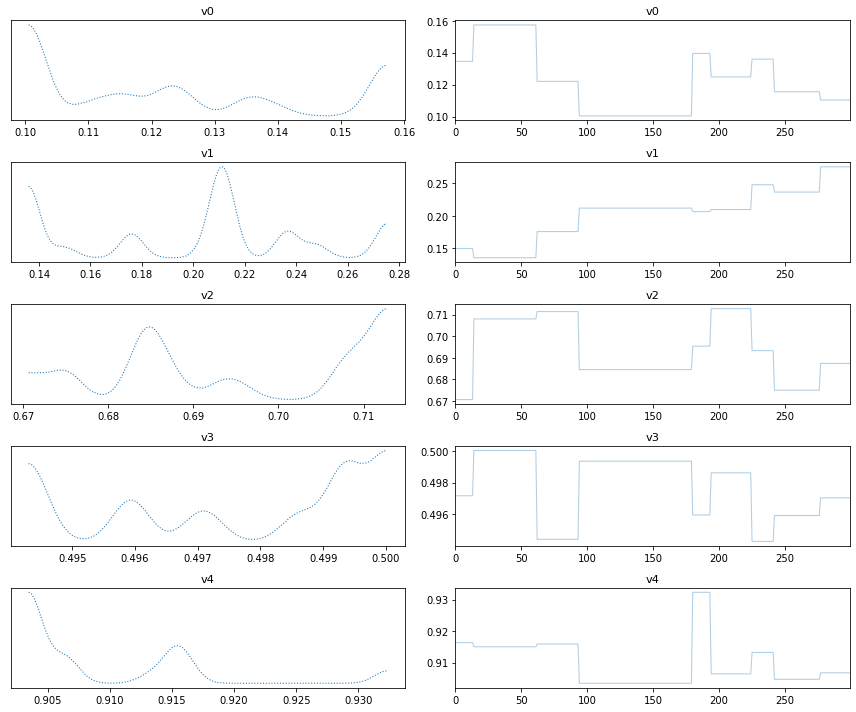

In [ ]:
# A_MF=Model(forward=final_model.prediction, range_geometry=Continuous1D(5), domain_geometry=Continuous1D(5))
# x_MF=Uniform(np.array([0.,0.,0.,0.,0.]),np.array([1.,1.,1.,1.,1.]))
# y_MF=Gaussian(mean=A_MF(x_MF),cov=proposal_sd)
# y_obs=y_MF(x_MF=real_x).sample()
# posterior_MF=JointDistribution(y_MF,x_MF)(y_MF=y_obs)
# x_init=np.array([initial_x,initial_x,initial_x,initial_x,initial_x])

# MHsampler_MF=MH(posterior_MF,x0=x_init)
# samplesMH_MF=MHsampler_MF.sample_adapt(n_samples,n_samples)

# samplesMH_MF.plot_trace()
# samplesMH_MF.mean()
# samplesMH_MF.compute_ess()
# samplesMH_MF.plot_autocorrelation()

A_MF=Model(forward=final_model.prediction, range_geometry=Continuous1D(5), domain_geometry=Continuous1D(5))
x_MF=Uniform(np.array([0.,0.,0.,0.,0.]),np.array([1.,1.,1.,1.,1.]))
num_bins = 10

for sd in proposal_sds:
    print(                f"********************  # Variance = {sd}  ********************"
                )
    y_MF=Gaussian(mean=A_MF(x_MF),cov=sd)
    y_obs=y_MF(x_MF=real_x).sample()
    posterior_MF=JointDistribution(y_MF,x_MF)(y_MF=y_obs)
    x_init=np.array([initial_x,initial_x,initial_x,initial_x,initial_x])

    for N in n_samples:
        print(                f"********************  # Steps = {N}  ********************"
                )
        MHsampler_MF=MH(posterior_MF,x0=x_init)
        estimates=np.empty((x_init.shape[0],0))
        chains=np.empty((0,x_init.shape[0],N))
        post=np.empty((x_init.shape[0],0))
        for i in range(chain_length):
                samplesMH_MF=MHsampler_MF.sample_adapt(N,int(N/2))    # N: number of "real" steps Nb: number of burn-in steps # total nb of steps is the sum of the two
                estimates=np.column_stack((estimates,samplesMH_MF.mean()[:, np.newaxis]))
                # chains=np.concatenate(chains, samplesMH_LF.samples)
                chains = np.concatenate((chains, np.expand_dims(samplesMH_MF.samples, axis=0)), axis=0)

                post=np.concatenate((post,samplesMH_MF.samples),axis=1)
        
        print(                f"********************  # Mean values = {estimates.mean(axis=1)}  ********************"
                )
          
        for num in range(post.shape[0]):        
                bin_edges = np.linspace(np.min(post[num,:]), np.max(post[num,:]), num_bins + 1)
                hist, _ = np.histogram(post, bins=bin_edges)
                hist=hist/post.shape[1]
                bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
                plt.figure()
                plt.bar(bin_centers, hist, width=np.diff(bin_edges), edgecolor='black', label=f'Var {num + 1}')

                plt.xlabel('Value')
                plt.ylabel('Probability')
                plt.title('Distribution')
                plt.legend()
                plt.show()
                
                plt.figure()
                plt.plot(np.mean(chains,axis=(0,2)))
                plt.xlabel('Step')
                plt.title(f'Averaged chain var {num+1}')
                plt.show()

              

# Nonlinear correlation

OBS: "periodic" case seems not to work

In [ ]:
lowfid = lambda x: np.sin(8*np.pi*x)
highfid = lambda x: (x-np.sqrt(2))*lowfid(x)**2
Nhf = 15
Nlf = 64
N = Nhf + Nlf
xhf = np.linspace(0,1,Nhf)
xlf = np.linspace(0,1,Nlf)
x_test = np.linspace(0,1,1000)
Yhf = highfid(xhf)
Ylf = lowfid(xlf)
NepoLF = 3000
NepoHF = 3000

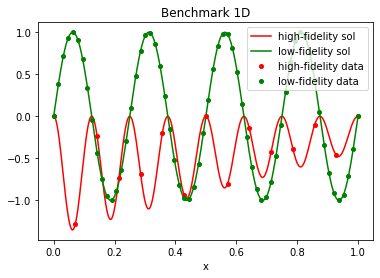

In [ ]:
#%% Plot functions
plt.figure()
plt.plot(x_test,highfid(x_test),'r', label = 'high-fidelity sol')
plt.plot(x_test,lowfid(x_test),'g', label = 'low-fidelity sol')
plt.plot(xhf,highfid(xhf),'ro', label = 'high-fidelity data', markersize = 4)
plt.plot(xlf,lowfid(xlf),'go', label = 'low-fidelity data', markersize = 4)
plt.xlabel('x')
plt.legend()
plt.title('Benchmark 1D')
plt.show()

## Low fidelity model

In [ ]:
bestLF_params = {'lr' : 0.0255, 'kernel_init' : 'glorot_uniform', 'opt' : 'Adam'}
modelLF=Neural_network('LF',params=bestLF_params,data_train=xlf,output_train=Ylf,N=NepoLF,n=Nlf,train=True,do_HPO=False,verbose=False)
yLF=modelLF.prediction(x_test)

## High fidelity model

In [ ]:
bestHF_params = {'lr' : 0.0255, 'kernel_init' : 'glorot_uniform', 'opt' : 'Adam'}
modelHF=Neural_network('LF',params=bestHF_params,data_train=xhf,output_train=Yhf,N=NepoHF,n=Nhf,train=True,do_HPO=False,verbose=False)
yHF=modelHF.prediction(x_test)

## 2 Step model

In [ ]:
bestLF_params = {'lr' : 0.0255, 'kernel_init' : 'glorot_uniform', 'opt' : 'Adam'}
best_params = {'kernel_init': 'uniform', 'l2weight': 0.00010018625799978436, 'lr': 0.07093837044166487, 'nodes': 74.0, 'opt': 'Adamax'}
N=[NepoLF,NepoHF]
n=[Nlf,Nhf]
names=['LF','2step']

params=[bestLF_params,best_params]
final_model=MultiFidelity(names,params=params,data_train_LF=xlf,output_train_LF=Ylf,data_train_HF=xhf,output_train_HF=Yhf,N=N,n=n,do_HPO=False,verbose=False)
y_test=final_model.prediction(x_test)

## Plots

Text(0.5, 1.0, 'High fidelity model - 2-step')

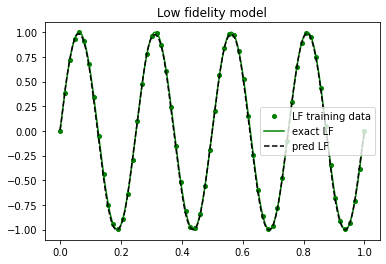

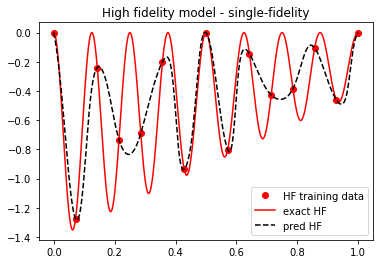

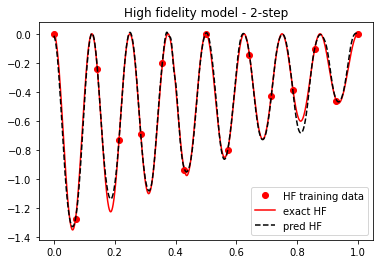

In [ ]:
#LF
plt.figure()
plt.plot(xlf,Ylf,'go', label = 'LF training data', markersize = 4)
plt.plot(x_test,lowfid(x_test),'g', label = 'exact LF') 
plt.plot(x_test,yLF,'k--', label = 'pred LF')
plt.legend()
plt.title('Low fidelity model')

#HF single-fidelity
plt.figure()
plt.plot(xhf,Yhf,'ro', label = 'HF training data')
plt.plot(x_test,highfid(x_test),'-r', label = 'exact HF')
plt.plot(x_test,yHF,'--k', label = 'pred HF')
plt.legend()
plt.title('High fidelity model - single-fidelity')

#2-step MF
plt.figure()
plt.plot(xhf,Yhf,'ro', label = 'HF training data')
plt.plot(x_test,highfid(x_test),'-r', label = 'exact HF')
plt.plot(x_test,y_test,'--k', label = 'pred HF')
plt.legend()
plt.title('High fidelity model - 2-step')

# MCMC

In [ ]:
real_x = np.array([0.1,0.3,0.5,0.7,0.9])
observed_output = highfid(real_x)

# Set parameters for the MCMC
n_samples = 300  # Number of samples
initial_x = 0.5 # Initial value for x
proposal_sd = 0.3 # Standard deviation for the proposal distribution

### Low Fidelity

Sample 600 / 600

Average acceptance rate: 0.20333333333333334 MCMC scale: 0.044338058911932175 



array([0.84160488, 0.80779625, 0.53927116, 0.42907475, 0.4357142 ])

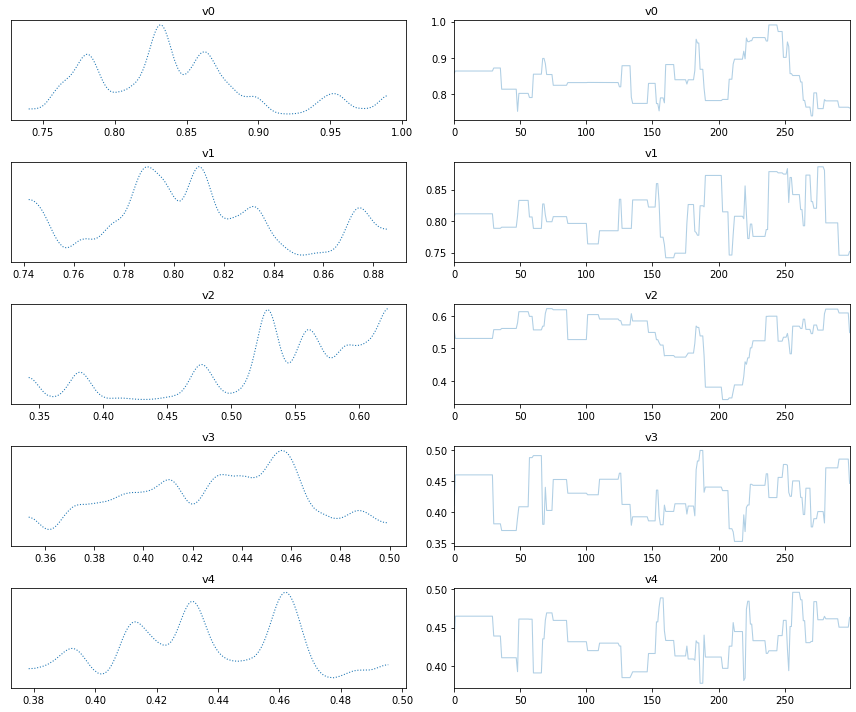

In [ ]:
# A_LF=Model(forward=modelLF.prediction, range_geometry=Continuous1D(5), domain_geometry=Continuous1D(5))
# x_LF=Uniform(np.array([0.,0.,0.,0.,0.]),np.array([1.,1.,1.,1.,1.]))
# y_LF=Gaussian(mean=A_LF(x_LF),cov=proposal_sd)
# y_obs=y_LF(x_LF=real_x).sample()
# posterior_LF=JointDistribution(y_LF,x_LF)(y_LF=y_obs)
# x_init=np.array([initial_x,initial_x,initial_x,initial_x,initial_x])

# MHsampler_LF=MH(posterior_LF,x0=x_init)
# samplesMH_LF=MHsampler_LF.sample_adapt(n_samples,n_samples)

# samplesMH_LF.plot_trace()
# samplesMH_LF.mean()
# samplesMH_LF.compute_ess()
# samplesMH_LF.plot_autocorrelation()

A_LF=Model(forward=modelLF.prediction, range_geometry=Continuous1D(5), domain_geometry=Continuous1D(5))
x_LF=Uniform(np.array([0.,0.,0.,0.,0.]),np.array([1.,1.,1.,1.,1.]))
num_bins = 10

for sd in proposal_sds:
    print(                f"********************  # Variance = {sd}  ********************"
                )
    y_LF=Gaussian(mean=A_LF(x_LF),cov=sd)
    y_obs=y_LF(x_LF=real_x).sample()
    posterior_LF=JointDistribution(y_LF,x_LF)(y_LF=y_obs)
    x_init=np.array([initial_x,initial_x,initial_x,initial_x,initial_x])

    for N in n_samples:
        print(                f"********************  # Steps = {N}  ********************"
                )
        MHsampler_LF=MH(posterior_LF,x0=x_init)
        estimates=np.empty((x_init.shape[0],0))
        chains=np.empty((0,x_init.shape[0],N))
        post=np.empty((x_init.shape[0],0))
        for i in range(chain_length):
                samplesMH_LF=MHsampler_LF.sample_adapt(N,int(N/2))    # N: number of "real" steps Nb: number of burn-in steps # total nb of steps is the sum of the two
                estimates=np.column_stack((estimates,samplesMH_LF.mean()[:, np.newaxis]))
                # chains=np.concatenate(chains, samplesMH_LF.samples)
                chains = np.concatenate((chains, np.expand_dims(samplesMH_LF.samples, axis=0)), axis=0)

                post=np.concatenate((post,samplesMH_LF.samples),axis=1)
        
        print(                f"********************  # Mean values = {estimates.mean(axis=1)}  ********************"
                )
          
        for num in range(post.shape[0]):        
                bin_edges = np.linspace(np.min(post[num,:]), np.max(post[num,:]), num_bins + 1)
                hist, _ = np.histogram(post, bins=bin_edges)
                hist=hist/post.shape[1]
                bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
                plt.figure()
                plt.bar(bin_centers, hist, width=np.diff(bin_edges), edgecolor='black', label=f'Var {num + 1}')

                plt.xlabel('Value')
                plt.ylabel('Probability')
                plt.title('Distribution')
                plt.legend()
                plt.show()
                
                plt.figure()
                plt.plot(np.mean(chains,axis=(0,2)))
                plt.xlabel('Step')
                plt.title(f'Averaged chain var {num+1}')
                plt.show()

    

### High Fidelity

Sample 600 / 600

Average acceptance rate: 0.25 MCMC scale: 0.21325997508682226 



array([0.54189218, 0.52391214, 0.30068936, 0.57129462, 0.48135374])

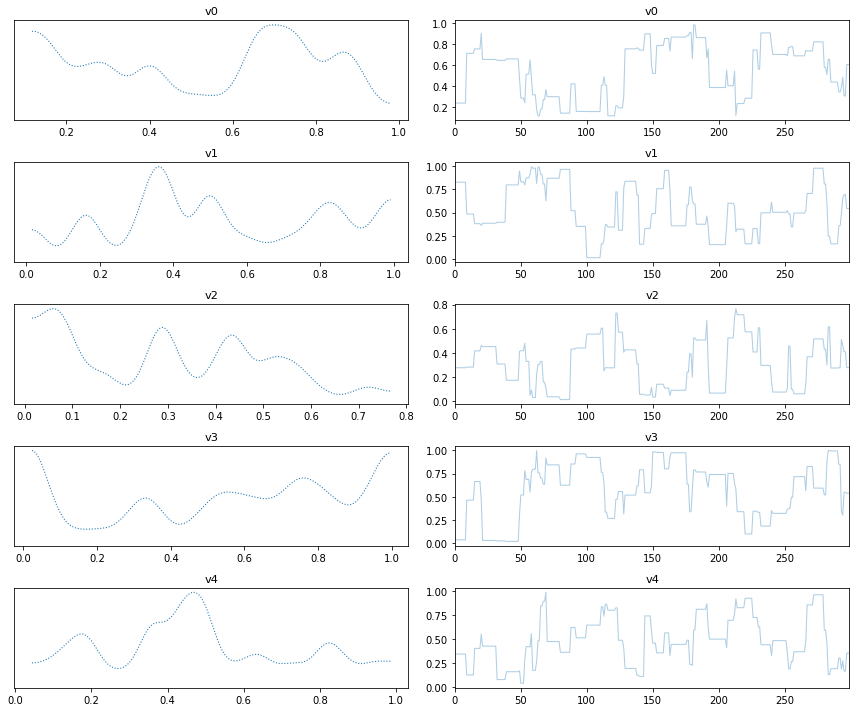

In [ ]:
# A_HF=Model(forward=modelHF.prediction, range_geometry=Continuous1D(5), domain_geometry=Continuous1D(5))
# x_HF=Uniform(np.array([0.,0.,0.,0.,0.]),np.array([1.,1.,1.,1.,1.]))
# y_HF=Gaussian(mean=A_HF(x_HF),cov=proposal_sd)
# y_obs=y_HF(x_HF=real_x).sample()
# posterior_HF=JointDistribution(y_HF,x_HF)(y_HF=y_obs)
# x_init=np.array([initial_x,initial_x,initial_x,initial_x,initial_x])

# MHsampler_HF=MH(posterior_HF,x0=x_init)
# samplesMH_HF=MHsampler_HF.sample_adapt(n_samples,n_samples)

# samplesMH_HF.plot_trace()
# samplesMH_HF.mean()
# samplesMH_HF.compute_ess()
# samplesMH_HF.plot_autocorrelation()

A_HF=Model(forward=modelHF.prediction, range_geometry=Continuous1D(5), domain_geometry=Continuous1D(5))
x_HF=Uniform(np.array([0.,0.,0.,0.,0.]),np.array([1.,1.,1.,1.,1.]))
num_bins = 10

for sd in proposal_sds:
    print(                f"********************  # Variance = {sd}  ********************"
                )
    y_HF=Gaussian(mean=A_HF(x_HF),cov=sd)
    y_obs=y_HF(x_HF=real_x).sample()
    posterior_HF=JointDistribution(y_HF,x_HF)(y_HF=y_obs)
    x_init=np.array([initial_x,initial_x,initial_x,initial_x,initial_x])

    for N in n_samples:
        print(                f"********************  # Steps = {N}  ********************"
                )
        MHsampler_HF=MH(posterior_HF,x0=x_init)
        estimates=np.empty((x_init.shape[0],0))
        chains=np.empty((0,x_init.shape[0],N))
        post=np.empty((x_init.shape[0],0))
        for i in range(chain_length):
                samplesMH_HF=MHsampler_LF.sample_adapt(N,int(N/2))    # N: number of "real" steps Nb: number of burn-in steps # total nb of steps is the sum of the two
                estimates=np.column_stack((estimates,samplesMH_HF.mean()[:, np.newaxis]))
                # chains=np.concatenate(chains, samplesMH_LF.samples)
                chains = np.concatenate((chains, np.expand_dims(samplesMH_HF.samples, axis=0)), axis=0)

                post=np.concatenate((post,samplesMH_HF.samples),axis=1)
        
        print(                f"********************  # Mean values = {estimates.mean(axis=1)}  ********************"
                )
          
        for num in range(post.shape[0]):        
                bin_edges = np.linspace(np.min(post[num,:]), np.max(post[num,:]), num_bins + 1)
                hist, _ = np.histogram(post, bins=bin_edges)
                hist=hist/post.shape[1]
                bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
                plt.figure()
                plt.bar(bin_centers, hist, width=np.diff(bin_edges), edgecolor='black', label=f'Var {num + 1}')

                plt.xlabel('Value')
                plt.ylabel('Probability')
                plt.title('Distribution')
                plt.legend()
                plt.show()
                
                plt.figure()
                plt.plot(np.mean(chains,axis=(0,2)))
                plt.xlabel('Step')
                plt.title(f'Averaged chain var {num+1}')
                plt.show()


### MultiFidelity

Sample 600 / 600

Average acceptance rate: 0.22 MCMC scale: 0.16918775217902313 



array([0.38688878, 0.60391827, 0.34670587, 0.55301021, 0.44463978])

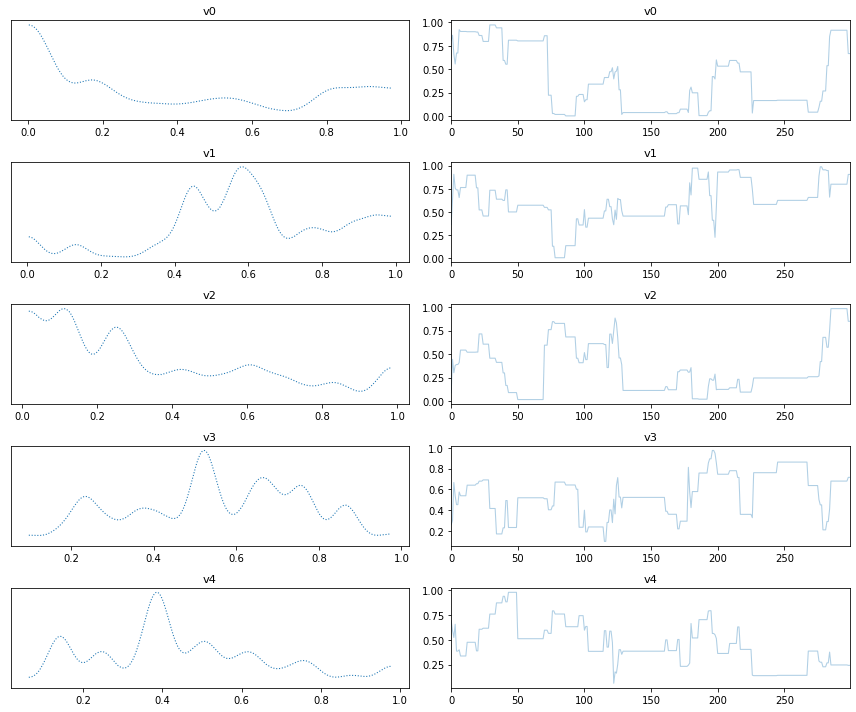

In [ ]:
# A_MF=Model(forward=final_model.prediction, range_geometry=Continuous1D(5), domain_geometry=Continuous1D(5))
# x_MF=Uniform(np.array([0.,0.,0.,0.,0.]),np.array([1.,1.,1.,1.,1.]))
# y_MF=Gaussian(mean=A_MF(x_MF),cov=proposal_sd)
# y_obs=y_MF(x_MF=real_x).sample()
# posterior_MF=JointDistribution(y_MF,x_MF)(y_MF=y_obs)
# x_init=np.array([initial_x,initial_x,initial_x,initial_x,initial_x])

# MHsampler_MF=MH(posterior_MF,x0=x_init)
# samplesMH_MF=MHsampler_MF.sample_adapt(n_samples,n_samples)

# samplesMH_MF.plot_trace()
# samplesMH_MF.mean()
# samplesMH_MF.compute_ess()
# samplesMH_MF.plot_autocorrelation()

A_MF=Model(forward=final_model.prediction, range_geometry=Continuous1D(5), domain_geometry=Continuous1D(5))
x_MF=Uniform(np.array([0.,0.,0.,0.,0.]),np.array([1.,1.,1.,1.,1.]))
num_bins = 10

for sd in proposal_sds:
    print(                f"********************  # Variance = {sd}  ********************"
                )
    y_MF=Gaussian(mean=A_MF(x_MF),cov=sd)
    y_obs=y_MF(x_MF=real_x).sample()
    posterior_MF=JointDistribution(y_MF,x_MF)(y_MF=y_obs)
    x_init=np.array([initial_x,initial_x,initial_x,initial_x,initial_x])

    for N in n_samples:
        print(                f"********************  # Steps = {N}  ********************"
                )
        MHsampler_MF=MH(posterior_MF,x0=x_init)
        estimates=np.empty((x_init.shape[0],0))
        chains=np.empty((0,x_init.shape[0],N))
        post=np.empty((x_init.shape[0],0))
        for i in range(chain_length):
                samplesMH_MF=MHsampler_MF.sample_adapt(N,int(N/2))    # N: number of "real" steps Nb: number of burn-in steps # total nb of steps is the sum of the two
                estimates=np.column_stack((estimates,samplesMH_MF.mean()[:, np.newaxis]))
                # chains=np.concatenate(chains, samplesMH_LF.samples)
                chains = np.concatenate((chains, np.expand_dims(samplesMH_MF.samples, axis=0)), axis=0)

                post=np.concatenate((post,samplesMH_MF.samples),axis=1)
        
        print(                f"********************  # Mean values = {estimates.mean(axis=1)}  ********************"
                )
          
        for num in range(post.shape[0]):        
                bin_edges = np.linspace(np.min(post[num,:]), np.max(post[num,:]), num_bins + 1)
                hist, _ = np.histogram(post, bins=bin_edges)
                hist=hist/post.shape[1]
                bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
                plt.figure()
                plt.bar(bin_centers, hist, width=np.diff(bin_edges), edgecolor='black', label=f'Var {num + 1}')

                plt.xlabel('Value')
                plt.ylabel('Probability')
                plt.title('Distribution')
                plt.legend()
                plt.show()
                
                plt.figure()
                plt.plot(np.mean(chains,axis=(0,2)))
                plt.xlabel('Step')
                plt.title(f'Averaged chain var {num+1}')
                plt.show()

              